# Master raster-to-vector comparison at ML threshold 0.95

This notebook combines the junction-aware MLP/CNN workflow with the classical vectorisation methods.

Key changes:

- MLP and CNN junction confidence are fixed at **0.95**. The old threshold sweep is removed.
- The master comparison sorts by the engineering drawing score, not raw pixel accuracy.
- Each method can be exported to **one SVG file with separate Inkscape-compatible layers**.
- The synthetic dataset is straight-line only, matching the current engineering drawing goal.

In [1]:
# Optional install cell. Run only if imports fail.
# %pip install numpy pandas matplotlib scipy scikit-image torch tqdm

In [2]:
import random
import math
import time
import re
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import binary_dilation
from skimage import measure
from skimage.morphology import skeletonize, disk, remove_small_objects
from skimage.transform import probabilistic_hough_line

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

try:
    from IPython.display import display
except Exception:
    display = print

# Set to None for new random data every run.
SEED = 11
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

IMG_SIZE = 128
MAX_VECTORS = 20
LINE_WIDTH = 1

N_TRAIN_IMAGES = 200
N_TEST = 40

PATCH_SIZE = 9
PATCH_RADIUS = PATCH_SIZE // 2
JUNCTION_RADIUS = 2

BATCH_SIZE = 512
MLP_EPOCHS = 3
CNN_EPOCHS = 3
LEARNING_RATE = 1e-3

# Controls the final vector cleanup.
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

# Classical method controls.
RDP_EPSILON = 1.25
SPARSE_STRIDE = 5
MESH_GRID = 8
RASTER_WIDTH = LINE_WIDTH
FIXED_ML_THRESHOLD = 0.95

torch.set_num_threads(1)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Fixed MLP/CNN threshold:', FIXED_ML_THRESHOLD)

Device: cpu
Fixed MLP/CNN threshold: 0.95


## 1. Engineering drawing geometry controls

Angles are measured in whole degrees and lengths in whole pixels. The scoring weights make 90° geometry most important, then 45°, 60°, 30°, 10°, and finally arbitrary 1° angles.

In [3]:
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,
    "length_unit_px": 1,
    "angle_unit_weights": {
        90: 5.0,
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        base = random.choice(list(range(0, 180, chosen_unit)))

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]

## 2. Synthetic straight-line engineering drawings

The target vector list is the ground truth. The raster is only the observed input image.

(200, 128, 128) 200 (40, 128, 128) 40


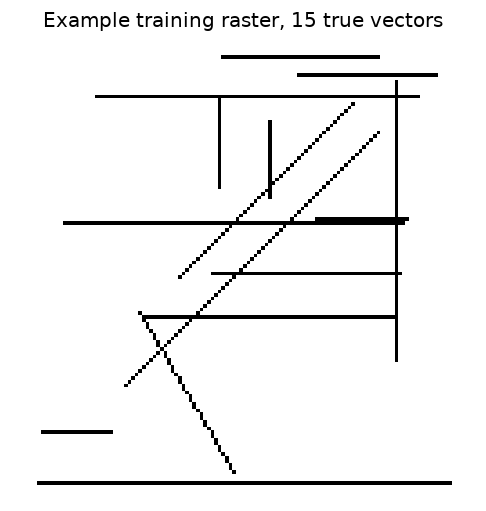

In [4]:
def clip_point(x, y, img_size=IMG_SIZE):
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


def bresenham_line(x0, y0, x1, y1):
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def rasterise_vectors(vectors, img_size=IMG_SIZE):
    image = np.ones((img_size, img_size), dtype=np.float32)
    for x0, y0, x1, y1 in vectors:
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)
        for x, y in bresenham_line(x0, y0, x1, y1):
            image[y, x] = 0.0
    return image


def random_line(img_size=IMG_SIZE, min_len=12, config=GEOMETRY_CONFIG):
    margin = 4
    max_len = img_size - 12

    for _ in range(500):
        angle_deg = sample_weighted_angle_deg(config)
        angle_rad = math.radians(angle_deg)
        length = snap_length_px(random.randint(min_len, max_len), config["length_unit_px"])

        dx = math.cos(angle_rad) * length / 2
        dy = math.sin(angle_rad) * length / 2

        min_cx = margin + abs(dx)
        max_cx = img_size - 1 - margin - abs(dx)
        min_cy = margin + abs(dy)
        max_cy = img_size - 1 - margin - abs(dy)

        if min_cx > max_cx or min_cy > max_cy:
            continue

        cx = random.uniform(min_cx, max_cx)
        cy = random.uniform(min_cy, max_cy)

        x0, y0 = cx - dx, cy - dy
        x1, y1 = cx + dx, cy + dy

        if math.hypot(x1 - x0, y1 - y0) >= min_len:
            return (x0, y0, x1, y1)

    return (10.0, 10.0, float(img_size - 10), 10.0)


def generate_sample(max_vectors=MAX_VECTORS, img_size=IMG_SIZE):
    n = random.randint(1, max_vectors)
    vectors = [random_line(img_size) for _ in range(n)]
    image = rasterise_vectors(vectors, img_size)
    return image, vectors


def generate_dataset(n_samples):
    images, vectors = [], []
    for _ in range(n_samples):
        img, vec = generate_sample()
        images.append(img)
        vectors.append(vec)
    return np.stack(images), vectors

train_images, train_vectors = generate_dataset(N_TRAIN_IMAGES)
test_images, test_vectors = generate_dataset(N_TEST)

print(train_images.shape, len(train_vectors), test_images.shape, len(test_vectors))
plt.figure(figsize=(5, 5), dpi=120)
plt.imshow(train_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title(f'Example training raster, {len(train_vectors[0])} true vectors')
plt.axis('off')
plt.show()

## 3. Junction labels and patch dataset

The ML models classify local patches as junction/non-junction; they are not asked to predict all vector endpoints directly.

In [5]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < eps:
        return None
    px = ((x1*y2 - y1*x2) * (x3 - x4) - (x1 - x2) * (x3*y4 - y3*x4)) / den
    py = ((x1*y2 - y1*x2) * (y3 - y4) - (y1 - y2) * (x3*y4 - y3*x4)) / den
    if not (np.isfinite(px) and np.isfinite(py)):
        return None

    def between(p, q, r):
        return min(p, r) - 1e-6 <= q <= max(p, r) + 1e-6

    if between(x1, px, x2) and between(y1, py, y2) and between(x3, px, x4) and between(y3, py, y4):
        return px, py
    return None


def junction_mask_from_vectors(vectors, img_size=IMG_SIZE, radius=JUNCTION_RADIUS):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    points = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is not None:
                cx, cy = p
                if not (np.isfinite(cx) and np.isfinite(cy)):
                    continue
                if cx < -radius or cx > img_size + radius or cy < -radius or cy > img_size + radius:
                    continue
                points.append(p)
                y0 = max(0, int(math.floor(cy - radius)))
                y1 = min(img_size, int(math.ceil(cy + radius)) + 1)
                x0 = max(0, int(math.floor(cx - radius)))
                x1 = min(img_size, int(math.ceil(cx + radius)) + 1)
                for y in range(y0, y1):
                    for x in range(x0, x1):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                            mask[y, x] = 1.0
    return mask, points

train_junction_masks = []
for vecs in train_vectors:
    m, _ = junction_mask_from_vectors(vecs)
    train_junction_masks.append(m)
train_junction_masks = np.stack(train_junction_masks)


def threshold_stroke(image):
    # Unified convention: image is 1.0 background and 0.0 stroke.
    return (image <= 0.5).astype(np.uint8)


def extract_patch(mask, x, y, patch_size=PATCH_SIZE):
    r = patch_size // 2
    padded = np.pad(mask.astype(np.float32), r, mode='constant', constant_values=0)
    return padded[y:y+patch_size, x:x+patch_size]


def extract_patch_from_padded(padded_mask, x, y, patch_size=PATCH_SIZE):
    # Assumes padded_mask has PATCH_RADIUS pixels of zero padding on every side.
    return padded_mask[y:y+patch_size, x:x+patch_size]


def build_patch_dataset(images, junction_masks, max_pos_per_image=80, max_neg_stroke_per_image=80, max_neg_bg_per_image=80):
    X, y = [], []
    for img, jm in zip(images, junction_masks):
        stroke = threshold_stroke(img)
        padded_stroke = np.pad(stroke.astype(np.float32), PATCH_RADIUS, mode='constant', constant_values=0)
        pos = np.argwhere(jm > 0.5)
        stroke_neg = np.argwhere((stroke == 1) & (jm <= 0.5))
        bg_neg = np.argwhere((stroke == 0) & (jm <= 0.5))

        def sample_rows(arr, n):
            if len(arr) == 0:
                return []
            ids = np.random.choice(len(arr), size=min(n, len(arr)), replace=False)
            return arr[ids]

        for yy, xx in sample_rows(pos, max_pos_per_image):
            X.append(extract_patch_from_padded(padded_stroke, xx, yy))
            y.append(1.0)
        for yy, xx in sample_rows(stroke_neg, max_neg_stroke_per_image):
            X.append(extract_patch_from_padded(padded_stroke, xx, yy))
            y.append(0.0)
        for yy, xx in sample_rows(bg_neg, max_neg_bg_per_image):
            X.append(extract_patch_from_padded(padded_stroke, xx, yy))
            y.append(0.0)

    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y

X_patch, y_patch = build_patch_dataset(train_images, train_junction_masks)
print('Patch dataset:', X_patch.shape, y_patch.shape)
print('Positive rate:', y_patch.mean())

perm = np.random.permutation(len(X_patch))
X_patch = X_patch[perm]
y_patch = y_patch[perm]

split = int(len(X_patch) * 0.85)
X_train_patch, X_val_patch = X_patch[:split], X_patch[split:]
y_train_patch, y_val_patch = y_patch[:split], y_patch[split:]

Patch dataset: (42983, 9, 9) (42983,)
Positive rate: 0.26247585


## 4. Train MLP and CNN junction classifiers

In [6]:
class JunctionMLP(nn.Module):
    def __init__(self, patch_size=PATCH_SIZE):
        super().__init__()
        n = patch_size * patch_size
        self.net = nn.Sequential(
            nn.Linear(n, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x).squeeze(1)


class JunctionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 12, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(24 * PATCH_SIZE * PATCH_SIZE, 48)
        self.fc2 = nn.Linear(48, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True, cnn=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if cnn:
        X_t = X_t[:, None, :, :]
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def train_binary_model(model, train_loader, val_loader, epochs, lr=LEARNING_RATE):
    model = model.to(DEVICE)
    pos = float(y_train_patch.sum())
    neg = float(len(y_train_patch) - y_train_patch.sum())
    pos_weight = torch.tensor([max(1.0, neg / max(pos, 1.0))], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            losses.append(float(loss.detach().cpu()))

        model.eval()
        val_losses = []
        all_pred = []
        all_true = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                val_losses.append(float(loss.detach().cpu()))
                probs = torch.sigmoid(logits)
                all_pred.append((probs >= 0.5).detach().cpu().numpy())
                all_true.append(yb.detach().cpu().numpy())

        pred = np.concatenate(all_pred).astype(bool)
        true = np.concatenate(all_true).astype(bool)
        tp = np.logical_and(pred, true).sum()
        fp = np.logical_and(pred, ~true).sum()
        fn = np.logical_and(~pred, true).sum()
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-9)
        msg = f'Epoch {epoch:02d}: train_loss={np.mean(losses):.4f}, val_loss={np.mean(val_losses):.4f}, P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}'
        print(msg)
        history.append((np.mean(losses), np.mean(val_losses), precision, recall, f1))
    return model, history

mlp = JunctionMLP()
cnn = JunctionCNN()

mlp_train_loader = make_loader(X_train_patch, y_train_patch, cnn=False)
mlp_val_loader = make_loader(X_val_patch, y_val_patch, shuffle=False, cnn=False)
cnn_train_loader = make_loader(X_train_patch, y_train_patch, cnn=True)
cnn_val_loader = make_loader(X_val_patch, y_val_patch, shuffle=False, cnn=True)

print('Training MLP junction classifier')
mlp, mlp_history = train_binary_model(mlp, mlp_train_loader, mlp_val_loader, MLP_EPOCHS)

print('\nTraining CNN junction classifier')
cnn, cnn_history = train_binary_model(cnn, cnn_train_loader, cnn_val_loader, CNN_EPOCHS)

Training MLP junction classifier
Epoch 01: train_loss=0.8194, val_loss=0.5735, P=0.665, R=0.975, F1=0.791
Epoch 02: train_loss=0.3878, val_loss=0.2555, P=0.782, R=0.963, F1=0.863
Epoch 03: train_loss=0.2365, val_loss=0.2140, P=0.831, R=0.960, F1=0.891

Training CNN junction classifier
Epoch 01: train_loss=0.4602, val_loss=0.2593, P=0.823, R=0.965, F1=0.888
Epoch 02: train_loss=0.2559, val_loss=0.2395, P=0.851, R=0.938, F1=0.893
Epoch 03: train_loss=0.2263, val_loss=0.2024, P=0.840, R=0.980, F1=0.905


## 5. Junction prediction and junction-aware reconstruction

The default threshold is fixed to 0.95 and the master comparison uses only this threshold.

In [7]:
def expand_mask(mask, radius=1):
    out = mask.copy().astype(np.uint8)
    ys, xs = np.where(mask > 0)
    h, w = mask.shape
    for y, x in zip(ys, xs):
        for yy in range(max(0, y - radius), min(h, y + radius + 1)):
            for xx in range(max(0, x - radius), min(w, x + radius + 1)):
                if (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2:
                    out[yy, xx] = 1
    return out


def predict_junction_mask_mlp(image, model=mlp, threshold=FIXED_ML_THRESHOLD):
    stroke = threshold_stroke(image)
    patches = []
    coords = []
    ys, xs = np.where(stroke == 1)
    padded_stroke = np.pad(stroke.astype(np.float32), PATCH_RADIUS, mode='constant', constant_values=0)
    for y, x in zip(ys, xs):
        patches.append(extract_patch_from_padded(padded_stroke, x, y))
        coords.append((y, x))
    out = np.zeros_like(stroke, dtype=np.uint8)
    if not patches:
        return out
    X = torch.tensor(np.stack(patches).astype(np.float32), device=DEVICE)
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), 4096):
            p = torch.sigmoid(model(X[i:i+4096])).detach().cpu().numpy()
            probs.append(p)
    probs = np.concatenate(probs)
    for (y, x), p in zip(coords, probs):
        if p >= threshold:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def predict_junction_mask_cnn(image, model=cnn, threshold=FIXED_ML_THRESHOLD):
    stroke = threshold_stroke(image)
    patches = []
    coords = []
    ys, xs = np.where(stroke == 1)
    padded_stroke = np.pad(stroke.astype(np.float32), PATCH_RADIUS, mode='constant', constant_values=0)
    for y, x in zip(ys, xs):
        patches.append(extract_patch_from_padded(padded_stroke, x, y))
        coords.append((y, x))
    out = np.zeros_like(stroke, dtype=np.uint8)
    if not patches:
        return out
    X = torch.tensor(np.stack(patches).astype(np.float32)[:, None, :, :], device=DEVICE)
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), 4096):
            p = torch.sigmoid(model(X[i:i+4096])).detach().cpu().numpy()
            probs.append(p)
    probs = np.concatenate(probs)
    for (y, x), p in zip(coords, probs):
        if p >= threshold:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def neighbour_count(mask, y, x):
    h, w = mask.shape
    c = 0
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx == 0 and dy == 0:
                continue
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and mask[yy, xx]:
                c += 1
    return c


def baseline_graph_junction_mask(image):
    stroke = threshold_stroke(image)
    out = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if neighbour_count(stroke, y, x) >= 3:
            out[y, x] = 1
    return expand_mask(out, radius=1)

# Make the fixed threshold explicit even if you later call these functions through defaults.
predict_junction_mask_mlp.__defaults__ = (mlp, FIXED_ML_THRESHOLD)
predict_junction_mask_cnn.__defaults__ = (cnn, FIXED_ML_THRESHOLD)

In [8]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def connected_components(mask):
    mask = mask.astype(bool)
    h, w = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    comps = []
    for y in range(h):
        for x in range(w):
            if not mask[y, x] or seen[y, x]:
                continue
            q = deque([(y, x)])
            seen[y, x] = True
            comp = []
            while q:
                cy, cx = q.popleft()
                comp.append((cy, cx))
                for dx, dy in NEIGHBOURS_8:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and not seen[ny, nx]:
                        seen[ny, nx] = True
                        q.append((ny, nx))
            comps.append(comp)
    return comps


def make_node_map(stroke, junction_mask):
    h, w = stroke.shape
    node_map = -np.ones((h, w), dtype=np.int32)
    nodes = []

    for comp in connected_components(junction_mask & stroke):
        if len(comp) == 0:
            continue
        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        node_id = len(nodes)
        nodes.append({'type': 'junction', 'x': float(xs.mean()), 'y': float(ys.mean()), 'pixels': comp})
        for y, x in comp:
            node_map[y, x] = node_id

    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if node_map[y, x] >= 0:
            continue
        if neighbour_count(stroke, y, x) <= 1:
            node_id = len(nodes)
            nodes.append({'type': 'endpoint', 'x': float(x), 'y': float(y), 'pixels': [(y, x)]})
            node_map[y, x] = node_id
    return nodes, node_map


def fit_line_to_path(path_points):
    if len(path_points) < 2:
        return None
    pts = np.array([(x, y) for y, x in path_points], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def line_length(line):
    x0, y0, x1, y1 = line
    return math.hypot(x1 - x0, y1 - y0)


def angle_of(line):
    x0, y0, x1, y1 = line
    return math.atan2(y1 - y0, x1 - x0)


def angle_diff(a, b):
    d = abs(a - b) % math.pi
    return min(d, math.pi - d)


def endpoint_distance(l1, l2):
    a = [(l1[0], l1[1]), (l1[2], l1[3])]
    b = [(l2[0], l2[1]), (l2[2], l2[3])]
    return min(math.hypot(x1-x2, y1-y2) for x1,y1 in a for x2,y2 in b)


def merged_line(l1, l2):
    pts = np.array([(l1[0], l1[1]), (l1[2], l1[3]), (l2[0], l2[1]), (l2[2], l2[3])], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def merge_collinear_vectors_fast(vectors, angle_tol_deg=8, endpoint_tol=4):
    vectors = [v for v in vectors if line_length(v) >= MIN_VECTOR_LENGTH]
    angle_tol = math.radians(angle_tol_deg)
    for _ in range(MAX_MERGE_PASSES):
        used = [False] * len(vectors)
        new_vectors = []
        changed = False
        for i, vi in enumerate(vectors):
            if used[i]:
                continue
            current = vi
            used[i] = True
            for j in range(i + 1, len(vectors)):
                if used[j]:
                    continue
                vj = vectors[j]
                if angle_diff(angle_of(current), angle_of(vj)) <= angle_tol and endpoint_distance(current, vj) <= endpoint_tol:
                    current = merged_line(current, vj)
                    used[j] = True
                    changed = True
            if line_length(current) >= MIN_VECTOR_LENGTH:
                new_vectors.append(current)
        vectors = new_vectors
        if not changed:
            break
    return vectors


def trace_vectors_with_junctions(image, junction_mask):
    stroke = threshold_stroke(image)
    nodes, node_map = make_node_map(stroke, junction_mask.astype(np.uint8))
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def stroke_neighbours(y, x):
        out = []
        for dx, dy in NEIGHBOURS_8:
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
                out.append((yy, xx))
        return out

    for node_id, node in enumerate(nodes):
        for sy, sx in node['pixels']:
            for ny, nx in stroke_neighbours(sy, sx):
                if node_map[ny, nx] == node_id:
                    continue
                edge_key = tuple(sorted(((sy, sx), (ny, nx))))
                if edge_key in visited_edges:
                    continue

                path = [(sy, sx), (ny, nx)]
                visited_edges.add(edge_key)
                prev = (sy, sx)
                cur = (ny, nx)
                end_node = node_map[cur]
                steps = 0

                while end_node < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = stroke_neighbours(*cur)
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break
                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        nxt = node_candidates[0]
                    else:
                        unvisited = []
                        for p in candidates:
                            ek = tuple(sorted((cur, p)))
                            if ek not in visited_edges:
                                unvisited.append(p)
                        if not unvisited:
                            break
                        nxt = unvisited[0]

                    ek = tuple(sorted((cur, nxt)))
                    visited_edges.add(ek)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node = node_map[cur]
                    steps += 1

                if len(path) >= 2:
                    start_id = node_id
                    end_id = node_map[path[-1]]
                    raw_line = fit_line_to_path(path)
                    if raw_line is None:
                        continue
                    x0, y0, x1, y1 = raw_line
                    if start_id >= 0:
                        x0, y0 = nodes[start_id]['x'], nodes[start_id]['y']
                    if end_id >= 0:
                        x1, y1 = nodes[end_id]['x'], nodes[end_id]['y']
                    line = (x0, y0, x1, y1)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    debug = {'stroke': stroke, 'junction_mask': junction_mask, 'nodes': nodes, 'node_map': node_map, 'paths': paths}
    return merge_collinear_vectors_fast(vectors), debug


def reconstruct_vectors_from_image(image, method='baseline'):
    if method == 'baseline':
        jm = baseline_graph_junction_mask(image)
    elif method == 'mlp':
        jm = predict_junction_mask_mlp(image, threshold=FIXED_ML_THRESHOLD)
    elif method == 'cnn':
        jm = predict_junction_mask_cnn(image, threshold=FIXED_ML_THRESHOLD)
    else:
        raise ValueError('method must be baseline, mlp, or cnn')
    return trace_vectors_with_junctions(image, jm)

## 6. Classical vectorisation methods adapted to the same 0-stroke raster convention

In [9]:
def clean_stroke_binary(image, min_size=2):
    binary = threshold_stroke(image).astype(bool)
    if min_size > 0:
        binary = remove_small_objects(binary, min_size=min_size)
    return binary


def rdp_simplify(points, epsilon=1.0):
    points = np.asarray(points, dtype=float)
    if len(points) < 3:
        return points

    start = points[0]
    end = points[-1]
    line = end - start
    line_norm = np.linalg.norm(line)

    if line_norm == 0:
        distances = np.linalg.norm(points - start, axis=1)
    else:
        rel = points - start
        distances = np.abs(line[0] * rel[:, 1] - line[1] * rel[:, 0]) / line_norm

    index = int(np.argmax(distances))
    max_dist = distances[index]

    if max_dist > epsilon:
        left = rdp_simplify(points[:index + 1], epsilon)
        right = rdp_simplify(points[index:], epsilon)
        return np.vstack([left[:-1], right])
    return np.vstack([start, end])


def vectorise_hough(image):
    binary = clean_stroke_binary(image)
    skel = skeletonize(binary)
    kwargs = {'threshold': 4, 'line_length': 4, 'line_gap': 2, 'theta': np.deg2rad(np.arange(0, 180, 1))}
    try:
        lines = probabilistic_hough_line(skel, rng=SEED, **kwargs)
    except TypeError:
        lines = probabilistic_hough_line(skel, **kwargs)
    return [np.array([p0, p1], dtype=float) for p0, p1 in lines]


def vectorise_contours(image):
    binary = clean_stroke_binary(image)
    contours = measure.find_contours(binary.astype(float), level=0.5)
    polylines = []
    for contour in contours:
        if len(contour) < 2:
            continue
        xy = np.column_stack([contour[:, 1], contour[:, 0]])
        xy = rdp_simplify(xy, epsilon=RDP_EPSILON)
        if len(xy) >= 2:
            polylines.append(xy)
    return polylines


NEIGHBOUR_STEPS_8 = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1),
]


def skeleton_neighbours(pixel, pixel_set):
    r, c = pixel
    out = []
    for dr, dc in NEIGHBOUR_STEPS_8:
        q = (r + dr, c + dc)
        if q in pixel_set:
            out.append(q)
    return out


def edge_key(a, b):
    return tuple(sorted([a, b]))


def skeleton_to_paths(skel, simplify_epsilon=RDP_EPSILON):
    skel = np.asarray(skel).astype(bool)
    pixels = set(map(tuple, np.argwhere(skel)))
    if not pixels:
        return []

    neighbours = {p: skeleton_neighbours(p, pixels) for p in pixels}
    degrees = {p: len(neighbours[p]) for p in pixels}
    nodes = {p for p, d in degrees.items() if d != 2}
    visited_edges = set()
    paths = []

    def walk(start, nxt):
        path = [start, nxt]
        visited_edges.add(edge_key(start, nxt))
        prev, cur = start, nxt
        while cur not in nodes:
            candidates = [q for q in neighbours[cur] if q != prev]
            if not candidates:
                break
            q = candidates[0]
            e = edge_key(cur, q)
            if e in visited_edges:
                break
            visited_edges.add(e)
            path.append(q)
            prev, cur = cur, q
        return path

    for node in list(nodes):
        for nb in neighbours[node]:
            e = edge_key(node, nb)
            if e not in visited_edges:
                path = walk(node, nb)
                if len(path) >= 2:
                    paths.append(path)

    all_edges = set()
    for p in pixels:
        for q in neighbours[p]:
            all_edges.add(edge_key(p, q))

    for e in list(all_edges - visited_edges):
        a, b = e
        if edge_key(a, b) in visited_edges:
            continue
        path = walk(a, b)
        if len(path) >= 2:
            paths.append(path)

    polylines = []
    for path in paths:
        arr = np.asarray(path, dtype=float)
        xy = np.column_stack([arr[:, 1], arr[:, 0]])
        xy = rdp_simplify(xy, epsilon=simplify_epsilon)
        if len(xy) >= 2:
            polylines.append(xy)
    return polylines


def vectorise_skeleton(image):
    binary = clean_stroke_binary(image)
    skel = skeletonize(binary)
    return skeleton_to_paths(skel, simplify_epsilon=RDP_EPSILON)


def vectorise_run_graph(image, min_run=3):
    binary = clean_stroke_binary(image)
    skel = skeletonize(binary)
    h, w = skel.shape
    directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
    polylines = []

    for dr, dc in directions:
        for r in range(h):
            for c in range(w):
                if not skel[r, c]:
                    continue
                prev_r, prev_c = r - dr, c - dc
                if 0 <= prev_r < h and 0 <= prev_c < w and skel[prev_r, prev_c]:
                    continue

                rr, cc = r, c
                run = []
                while 0 <= rr < h and 0 <= cc < w and skel[rr, cc]:
                    run.append((rr, cc))
                    rr += dr
                    cc += dc

                if len(run) >= min_run:
                    start = run[0]
                    end = run[-1]
                    polylines.append(np.array([[start[1], start[0]], [end[1], end[0]]], dtype=float))
    return polylines


def vectorise_sparse_pixels(image, stride=SPARSE_STRIDE):
    binary = clean_stroke_binary(image)
    skel = skeletonize(binary)
    dense_paths = skeleton_to_paths(skel, simplify_epsilon=0.0)
    sparse_paths = []
    for path in dense_paths:
        path = np.asarray(path, dtype=float)
        if len(path) < 2:
            continue
        keep = list(range(0, len(path), stride))
        if keep[-1] != len(path) - 1:
            keep.append(len(path) - 1)
        sparse = path[keep]
        sparse = rdp_simplify(sparse, epsilon=RDP_EPSILON)
        if len(sparse) >= 2:
            sparse_paths.append(sparse)
    return sparse_paths


def vectorise_mesh_pattern(image, grid=MESH_GRID, min_pixels=2):
    binary = clean_stroke_binary(image)
    h, w = binary.shape
    cell_h = h / grid
    cell_w = w / grid
    polylines = []

    for gy in range(grid):
        for gx in range(grid):
            r0 = int(round(gy * cell_h))
            r1 = int(round((gy + 1) * cell_h))
            c0 = int(round(gx * cell_w))
            c1 = int(round((gx + 1) * cell_w))

            patch = binary[r0:r1, c0:c1]
            ys, xs = np.where(patch)
            if len(xs) < min_pixels:
                continue

            pts = np.column_stack([xs + c0, ys + r0]).astype(float)
            centre = pts.mean(axis=0)

            if len(pts) >= 2:
                centred = pts - centre
                cov = centred.T @ centred / max(len(pts) - 1, 1)
                eigvals, eigvecs = np.linalg.eigh(cov)
                direction = eigvecs[:, np.argmax(eigvals)]
                direction = direction / (np.linalg.norm(direction) + 1e-9)
                length = min(cell_w, cell_h) * 0.85
            else:
                direction = np.array([1.0, 0.0])
                length = min(cell_w, cell_h) * 0.5

            p0 = centre - direction * length / 2
            p1 = centre + direction * length / 2
            polylines.append(np.vstack([p0, p1]))
    return polylines

## 7. Unified metric helpers

Pixel scores are retained, but the main ranking is the engineering score: line angle/length, total length, junction angle agreement, and vector count.

In [10]:
def vector_length_px(v):
    x0, y0, x1, y1 = v
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(v, config=GEOMETRY_CONFIG):
    x0, y0, x1, y1 = v
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config["angle_unit_deg"])


def angle_distance_deg(a, b):
    d = abs(a - b) % 180
    return min(d, 180 - d)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    best = min(config["angle_unit_weights"].values())
    for unit, weight in config["angle_unit_weights"].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        err = angle_distance_deg(angle_deg, nearest)
        if err <= config["angle_unit_deg"] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denom = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denom)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(v)) for v in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(v)) for v in pred_vectors)
    denom = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denom)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for i, gt in enumerate(true_vectors):
        gt_len = snap_length_px(vector_length_px(gt), config["length_unit_px"])
        gt_ang = vector_angle_deg(gt, config)
        importance = angle_family_importance(gt_ang, config)

        for j, pred in enumerate(pred_vectors):
            pred_len = snap_length_px(vector_length_px(pred), config["length_unit_px"])
            pred_ang = vector_angle_deg(pred, config)
            angle_err = angle_distance_deg(gt_ang, pred_ang)
            length_err = abs(gt_len - pred_len)
            angle_part = max(0.0, 1.0 - angle_err / config["line_angle_tolerance_deg"])
            length_tol = max(config["length_unit_px"], config["length_tolerance_ratio"] * max(gt_len, 1.0))
            length_part = max(0.0, 1.0 - length_err / length_tol)
            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0
    for pair_score, importance, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        weighted_score += pair_score * importance

    total_importance = sum(angle_family_importance(vector_angle_deg(v, config), config) for v in true_vectors)
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    angles = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is None:
                continue
            a = vector_angle_deg(vectors[i], config)
            b = vector_angle_deg(vectors[j], config)
            d = angle_distance_deg(a, b)
            acute = min(d, 180 - d)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config["angle_unit_deg"]))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for i, a in enumerate(true_angles):
        for j, b in enumerate(pred_angles):
            err = abs(a - b)
            score = max(0.0, 1.0 - err / tolerance_deg)
            candidates.append((score, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    total = 0.0
    for score, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        total += score
    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)
    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(true_junction_angles, pred_junction_angles, config["junction_angle_tolerance_deg"])

    w = config["score_weights"]
    engineering_score = (
        w["line_geometry"] * line_geometry
        + w["total_length"] * length_total
        + w["junction_angles"] * junction_angles
        + w["vector_count"] * count
    )

    return {
        "engineering_score": engineering_score,
        "line_geometry_score": line_geometry,
        "total_length_score": length_total,
        "junction_angle_score": junction_angles,
        "vector_count_score": count,
        "true_junctions": len(true_junction_angles),
        "pred_junctions": len(pred_junction_angles),
    }


def pixel_raster_metrics(true_raster, pred_raster):
    true = true_raster < 0.5
    pred = pred_raster < 0.5
    tp = np.logical_and(true, pred).sum()
    fp = np.logical_and(~true, pred).sum()
    fn = np.logical_and(true, ~pred).sum()
    tn = np.logical_and(~true, ~pred).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)
    return precision, recall, f1, iou, accuracy


def lines_to_polylines(lines):
    return [np.array([[x0, y0], [x1, y1]], dtype=float) for x0, y0, x1, y1 in lines]


def polylines_to_segments(polylines):
    segments = []
    for poly in polylines:
        poly = np.asarray(poly, dtype=float)
        if len(poly) < 2:
            continue
        for a, b in zip(poly[:-1], poly[1:]):
            segments.append((float(a[0]), float(a[1]), float(b[0]), float(b[1])))
    return segments


def polyline_segment_count(polylines):
    return int(sum(max(0, len(np.asarray(p)) - 1) for p in polylines))


def rasterise_polylines(polylines, size=IMG_SIZE, width=RASTER_WIDTH):
    stroke = np.zeros((size, size), dtype=bool)
    for poly in polylines:
        poly = np.asarray(poly, dtype=float)
        if len(poly) < 2:
            continue
        for a, b in zip(poly[:-1], poly[1:]):
            length = float(np.linalg.norm(b - a))
            steps = max(int(length * 3), 2)
            xs = np.linspace(a[0], b[0], steps)
            ys = np.linspace(a[1], b[1], steps)
            xi = np.rint(xs).astype(int)
            yi = np.rint(ys).astype(int)
            valid = (xi >= 0) & (xi < size) & (yi >= 0) & (yi < size)
            stroke[yi[valid], xi[valid]] = True
    if width > 1:
        stroke = binary_dilation(stroke, disk(max(1, int(width // 2))))
    image = np.ones((size, size), dtype=np.float32)
    image[stroke] = 0.0
    return image

## 8. Master comparison at threshold 0.95 only

In [11]:
def method_baseline(image):
    vectors, _ = reconstruct_vectors_from_image(image, method='baseline')
    return lines_to_polylines(vectors)


def method_mlp_095(image):
    vectors, _ = reconstruct_vectors_from_image(image, method='mlp')
    return lines_to_polylines(vectors)


def method_cnn_095(image):
    vectors, _ = reconstruct_vectors_from_image(image, method='cnn')
    return lines_to_polylines(vectors)


MASTER_METHODS = {
    "Baseline junction graph": method_baseline,
    "MLP junction cleanup 0.95": method_mlp_095,
    "CNN junction cleanup 0.95": method_cnn_095,
    "Hough Transform": vectorise_hough,
    "Contour": vectorise_contours,
    "Skeletonisation": vectorise_skeleton,
    "Run-graph": vectorise_run_graph,
    "Sparse pixel": vectorise_sparse_pixels,
    "Mesh pattern": vectorise_mesh_pattern,
}


def evaluate_master_methods(images, true_vectors):
    rows = []
    outputs = defaultdict(dict)

    for sample_idx, (image, truth) in enumerate(zip(images, true_vectors)):
        for method_name, method_fn in MASTER_METHODS.items():
            start = time.perf_counter()
            polylines = method_fn(image)
            elapsed_ms = (time.perf_counter() - start) * 1000

            pred_segments = polylines_to_segments(polylines)
            pred_raster = rasterise_polylines(polylines, size=IMG_SIZE, width=RASTER_WIDTH)
            precision, recall, f1, iou, pixel_accuracy = pixel_raster_metrics(image, pred_raster)
            geom = engineering_metrics(truth, pred_segments, GEOMETRY_CONFIG)

            rows.append({
                "sample": sample_idx,
                "method": method_name,
                "ml_threshold": FIXED_ML_THRESHOLD if "junction cleanup" in method_name else np.nan,
                "true_vectors": len(truth),
                "pred_segments": len(pred_segments),
                "pred_polylines": len(polylines),
                "vector_count_error": abs(len(truth) - len(pred_segments)),
                **geom,
                "pixel_precision": precision,
                "pixel_recall": recall,
                "pixel_f1": f1,
                "pixel_iou": iou,
                "pixel_accuracy": pixel_accuracy,
                "time_ms": elapsed_ms,
            })
            outputs[sample_idx][method_name] = {
                "polylines": polylines,
                "segments": pred_segments,
                "raster": pred_raster,
            }
    return pd.DataFrame(rows), outputs

master_results_df, master_outputs = evaluate_master_methods(test_images, test_vectors)

master_summary_df = (
    master_results_df
    .groupby("method", as_index=True)
    .mean(numeric_only=True)
    .sort_values(["engineering_score", "line_geometry_score", "pixel_f1"], ascending=False)
    .round(4)
)

print("Master comparison sorted by engineering_score")
display(master_summary_df)

print("Per-sample master results")
display(master_results_df.sort_values(["engineering_score", "line_geometry_score"], ascending=False).round(4))

EXPORT_DIR = Path('master_vector_exports')
EXPORT_DIR.mkdir(exist_ok=True)
master_results_df.to_csv(EXPORT_DIR / 'master_comparison_results_threshold_095.csv', index=False)
master_summary_df.to_csv(EXPORT_DIR / 'master_comparison_summary_threshold_095.csv')
print('Saved CSV files to', EXPORT_DIR.resolve())

C:\Users\elmak\AppData\Local\Temp\ipykernel_51480\631675434.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_size)


Master comparison sorted by engineering_score


,sample,ml_threshold,true_vectors,pred_segments,pred_polylines,vector_count_error,engineering_score,line_geometry_score,total_length_score,junction_angle_score,vector_count_score,true_junctions,pred_junctions,pixel_precision,pixel_recall,pixel_f1,pixel_iou,pixel_accuracy,time_ms
method,,,,,,,,,,,,,,,,,,,
Baseline junction graph,19.5,NaN,10.1,11.650,11.650,1.800,0.8354,0.8408,0.9608,0.7003,0.8978,10.125,10.175,0.7827,0.8517,0.8142,0.7150,0.9839,9.1803
MLP junction cleanup 0.95,19.5,0.95,10.1,13.350,13.350,3.300,0.7220,0.7680,0.8722,0.4826,0.8127,10.125,8.675,0.7203,0.7208,0.7182,0.5915,0.9780,9.4469
CNN junction cleanup 0.95,19.5,0.95,10.1,13.500,13.500,3.450,0.7144,0.7497,0.8640,0.4905,0.8154,10.125,8.925,0.7113,0.7142,0.7098,0.5823,0.9773,18.0931
Run-graph,19.5,NaN,10.1,14.275,14.275,5.825,0.6683,0.7608,0.6720,0.4894,0.6920,10.125,10.875,0.9500,0.7202,0.8123,0.7202,0.9903,5.2619
Hough Transform,19.5,NaN,10.1,10.425,10.425,2.975,0.6366,0.7252,0.6592,0.4173,0.7410,10.125,3.225,0.9368,0.7039,0.7966,0.6967,0.9892,1.1061
Skeletonisation,19.5,NaN,10.1,57.900,57.800,48.150,0.5584,0.7139,0.6990,0.2438,0.3636,10.125,109.850,0.9339,0.7172,0.8046,0.7086,0.9897,3.1014
Sparse pixel,19.5,NaN,10.1,57.800,57.800,48.050,0.5577,0.7127,0.6979,0.2440,0.3639,10.125,109.750,0.9293,0.7134,0.8005,0.7029,0.9894,3.4648
Contour,19.5,NaN,10.1,42.100,8.150,32.100,0.5430,0.6501,0.6897,0.3300,0.3003,10.125,31.475,0.5582,0.5869,0.5682,0.4362,0.9668,2.6013
Mesh pattern,19.5,NaN,10.1,23.525,23.525,13.525,0.4364,0.5187,0.5676,0.2002,0.3939,10.125,0.150,0.6644,0.4587,0.5336,0.3942,0.9723,1.3743


Per-sample master results


,sample,method,ml_threshold,true_vectors,pred_segments,pred_polylines,vector_count_error,engineering_score,line_geometry_score,total_length_score,junction_angle_score,vector_count_score,true_junctions,pred_junctions,pixel_precision,pixel_recall,pixel_f1,pixel_iou,pixel_accuracy,time_ms
0,0,Baseline junction graph,NaN,1,1,1,0,1.00,1.0,1.0,1.0,1.0,0,0,1.0,1.0,1.0,1.0,1.000,3.3621
1,0,MLP junction cleanup 0.95,0.95,1,1,1,0,1.00,1.0,1.0,1.0,1.0,0,0,1.0,1.0,1.0,1.0,1.000,3.0735
2,0,CNN junction cleanup 0.95,0.95,1,1,1,0,1.00,1.0,1.0,1.0,1.0,0,0,1.0,1.0,1.0,1.0,1.000,6.5994
3,0,Hough Transform,NaN,1,1,1,0,1.00,1.0,1.0,1.0,1.0,0,0,1.0,1.0,1.0,1.0,1.000,1.7104
5,0,Skeletonisation,NaN,1,1,1,0,1.00,1.0,1.0,1.0,1.0,0,0,1.0,1.0,1.0,1.0,1.000,0.9494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,32,Contour,NaN,1,0,0,1,0.25,0.0,0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.998,0.2799
293,32,Skeletonisation,NaN,1,0,0,1,0.25,0.0,0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.998,0.2414
294,32,Run-graph,NaN,1,0,0,1,0.25,0.0,0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.998,3.9085
295,32,Sparse pixel,NaN,1,0,0,1,0.25,0.0,0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.998,0.3462


Saved CSV files to C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\master_vector_exports


## 9. Visual comparison plots

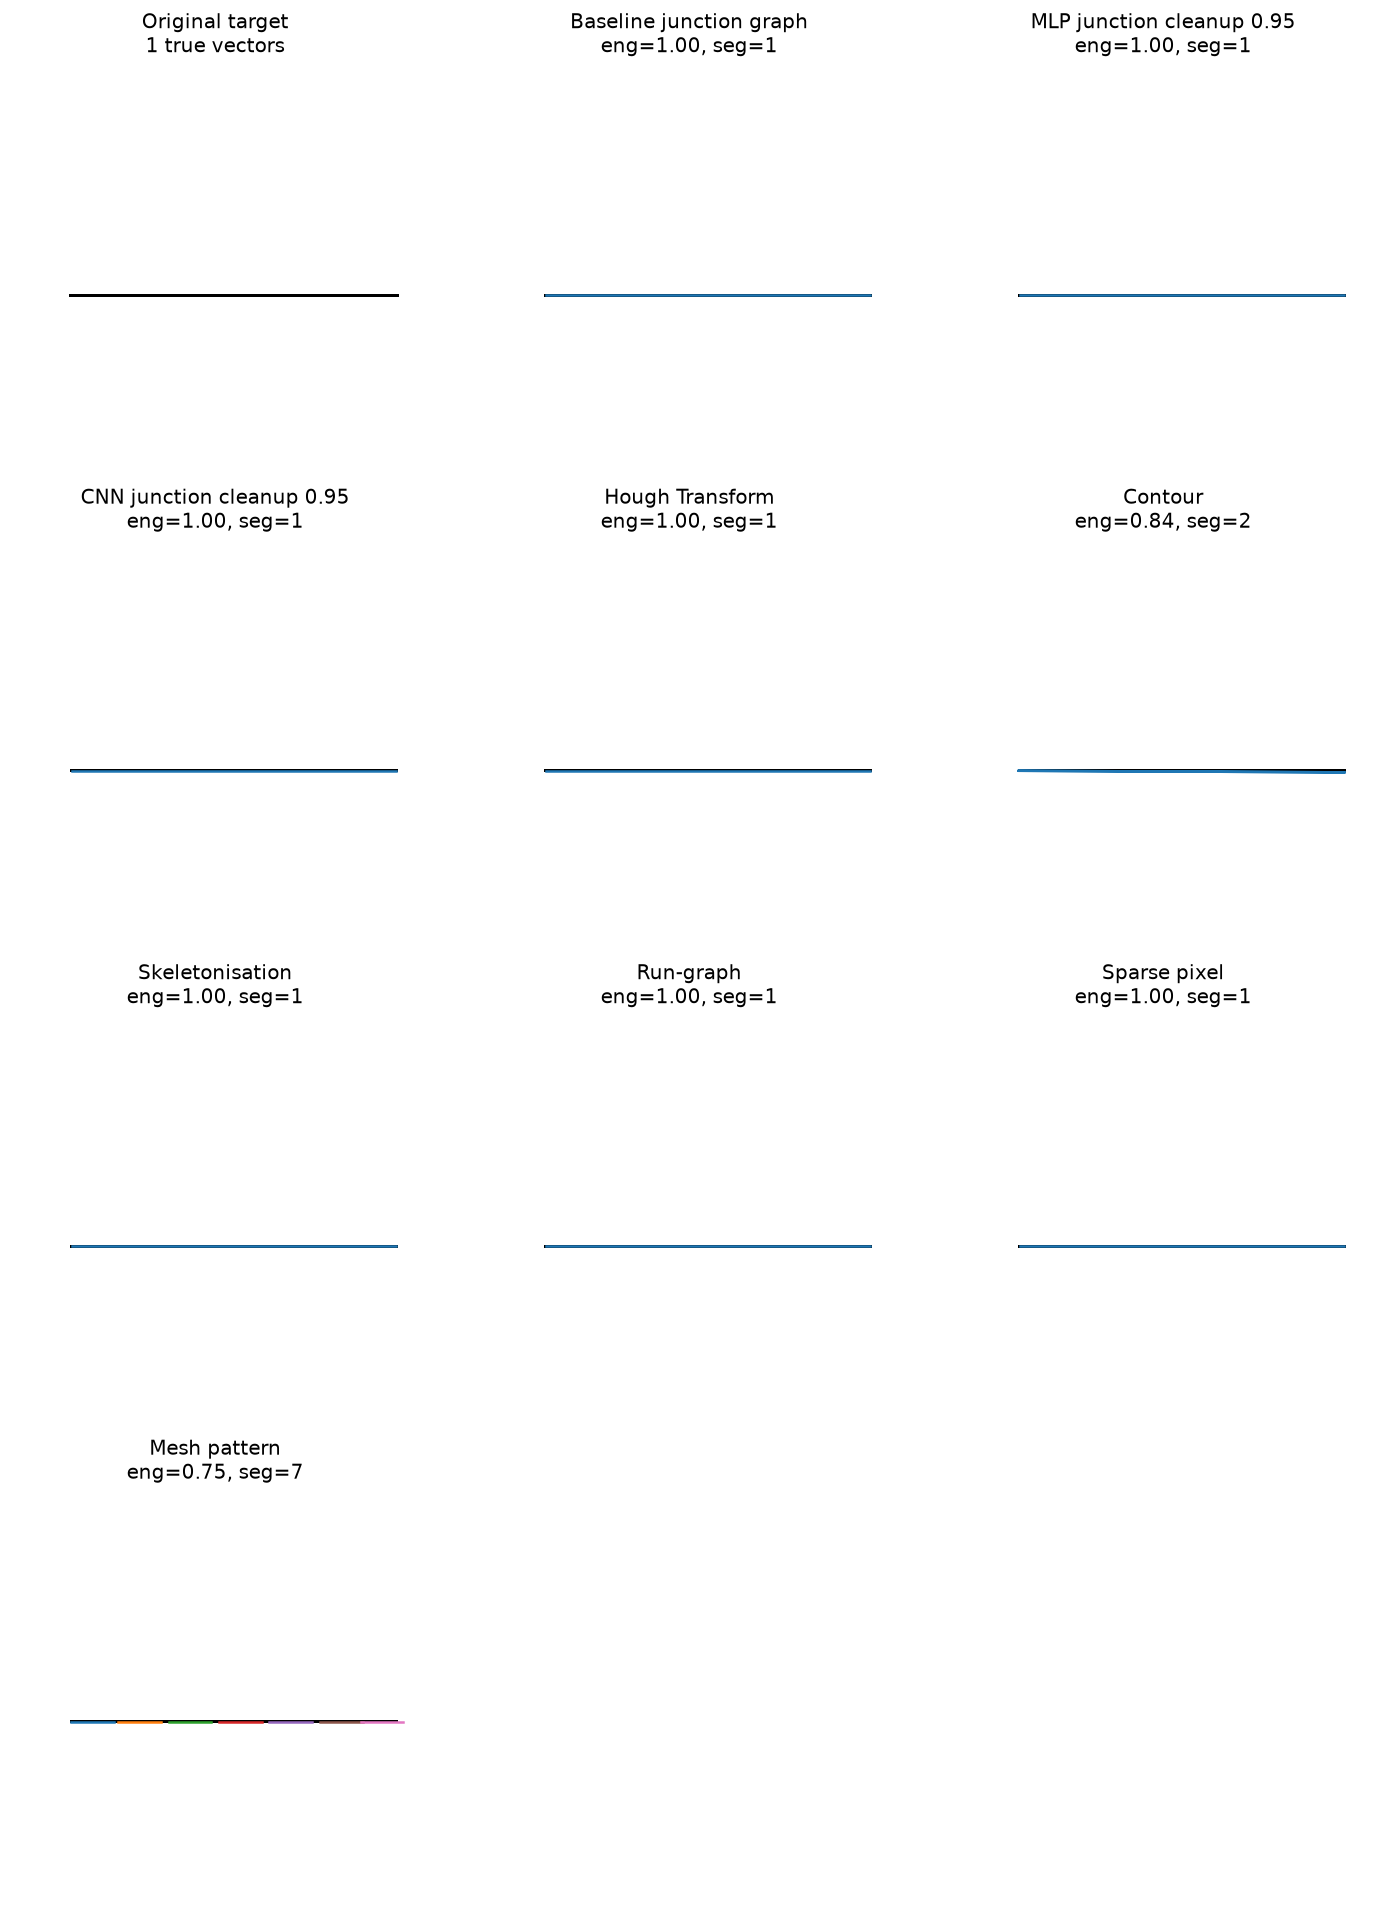

In [12]:
def plot_master_sample(sample_idx=0):
    method_names = list(MASTER_METHODS.keys())
    n_panels = 1 + len(method_names)
    cols = 3
    rows = int(math.ceil(n_panels / cols))
    plt.figure(figsize=(cols * 4, rows * 4), dpi=120)

    plt.subplot(rows, cols, 1)
    plt.imshow(test_images[sample_idx], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    plt.title(f'Original target\n{len(test_vectors[sample_idx])} true vectors')
    plt.axis('off')

    for i, name in enumerate(method_names, start=2):
        row = master_results_df[(master_results_df["sample"] == sample_idx) & (master_results_df.method == name)].iloc[0]
        plt.subplot(rows, cols, i)
        plt.imshow(test_images[sample_idx], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        for poly in master_outputs[sample_idx][name]['polylines']:
            poly = np.asarray(poly)
            if len(poly) >= 2:
                plt.plot(poly[:, 0], poly[:, 1], linewidth=1.5)
        plt.xlim(-1, IMG_SIZE)
        plt.ylim(IMG_SIZE, -1)
        plt.title(f'{name}\neng={row.engineering_score:.2f}, seg={int(row.pred_segments)}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_master_sample(0)

## 10. Single SVG export with one layer per method

Open the SVG in Inkscape or another SVG editor and toggle layers on/off. The SVG contains:

- one layer for original ground-truth vectors;
- one layer per reconstruction method;
- Inkscape layer metadata via `inkscape:groupmode="layer"` and `inkscape:label`.

In [13]:
SVG_NS = 'http://www.w3.org/2000/svg'
INKSCAPE_NS = 'http://www.inkscape.org/namespaces/inkscape'

ET.register_namespace('', SVG_NS)
ET.register_namespace('inkscape', INKSCAPE_NS)

# -----------------------------
# CONFIG
# -----------------------------

NUM_OUTPUT_EXAMPLES = 5      # Change this to 1, 3, 10, 20, etc.
START_SAMPLE_INDEX = 0       # First sample to export

# Use this if you want exact sample numbers instead.
# Example: SAMPLE_INDICES = [0, 4, 12, 20]
SAMPLE_INDICES = None

INCLUDE_BACKGROUND = True

SVG_SCALE = 6
SVG_STROKE_WIDTH = 1.0
TARGET_STROKE_WIDTH = 1.3

# -----------------------------
# SVG layer colours
# -----------------------------

LAYER_COLOURS = {
    'Original target vectors': '#1f77b4',
    'Baseline graph': '#d62728',
    'MLP junction cleanup 0.95': '#2ca02c',
    'CNN junction cleanup 0.95': '#9467bd',
    'Hough Transform': '#ff7f0e',
    'Contour': '#8c564b',
    'Skeletonisation': '#17becf',
    'Run-graph': '#e377c2',
    'Sparse pixel': '#7f7f7f',
    'Mesh pattern': '#bcbd22',
}


def safe_layer_id(name):
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_').lower()


def add_polyline_layer(
    svg,
    layer_name,
    polylines,
    colour,
    stroke_width=1.0,
    visible=True
):
    layer = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
        'id': safe_layer_id(layer_name),
        f'{{{INKSCAPE_NS}}}groupmode': 'layer',
        f'{{{INKSCAPE_NS}}}label': layer_name,
        'stroke': colour,
        'stroke-width': str(stroke_width),
        'fill': 'none',
        'stroke-linecap': 'round',
        'stroke-linejoin': 'round',
        'style': 'display:inline' if visible else 'display:none',
    })

    ET.SubElement(layer, f'{{{SVG_NS}}}title').text = layer_name

    for poly in polylines:
        poly = np.asarray(poly, dtype=float)

        if len(poly) < 2:
            continue

        pts = ' '.join(
            f'{float(x):.3f},{float(y):.3f}'
            for x, y in poly
        )

        ET.SubElement(layer, f'{{{SVG_NS}}}polyline', {
            'points': pts
        })

    return layer


def export_master_comparison_svg(
    sample_idx=0,
    filename=None,
    include_background=True
):
    if filename is None:
        filename = EXPORT_DIR / (
            f'sample_{sample_idx}_master_comparison_layers_threshold_095.svg'
        )

    filename = Path(filename)

    svg = ET.Element(f'{{{SVG_NS}}}svg', {
        'width': str(IMG_SIZE * SVG_SCALE),
        'height': str(IMG_SIZE * SVG_SCALE),
        'viewBox': f'0 0 {IMG_SIZE} {IMG_SIZE}',
        'version': '1.1',
    })

    if include_background:
        background = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
            'id': f'background_sample_{sample_idx}',
            f'{{{INKSCAPE_NS}}}groupmode': 'layer',
            f'{{{INKSCAPE_NS}}}label': 'Background',
            'style': 'display:inline',
        })

        ET.SubElement(background, f'{{{SVG_NS}}}rect', {
            'x': '0',
            'y': '0',
            'width': str(IMG_SIZE),
            'height': str(IMG_SIZE),
            'fill': 'white',
        })

    add_polyline_layer(
        svg,
        'Original target vectors',
        lines_to_polylines(test_vectors[sample_idx]),
        LAYER_COLOURS['Original target vectors'],
        stroke_width=TARGET_STROKE_WIDTH,
        visible=True,
    )

    for method_name in MASTER_METHODS.keys():
        add_polyline_layer(
            svg,
            method_name,
            master_outputs[sample_idx][method_name]['polylines'],
            LAYER_COLOURS.get(method_name, '#000000'),
            stroke_width=SVG_STROKE_WIDTH,
            visible=True,
        )

    tree = ET.ElementTree(svg)
    tree.write(filename, encoding='utf-8', xml_declaration=True)

    print(f'Saved layered SVG: {filename}')

    return filename


def export_multiple_master_comparison_svgs(
    num_examples=5,
    start_sample_index=0,
    sample_indices=None,
    include_background=True
):
    if sample_indices is None:
        sample_indices = list(
            range(start_sample_index, start_sample_index + num_examples)
        )
    else:
        sample_indices = list(sample_indices)

    saved_files = []

    for sample_idx in sample_indices:
        filename = EXPORT_DIR / (
            f'sample_{sample_idx}_master_comparison_layers_threshold_095.svg'
        )

        svg_file = export_master_comparison_svg(
            sample_idx=sample_idx,
            filename=filename,
            include_background=include_background,
        )

        saved_files.append(svg_file)

    return saved_files


svg_files = export_multiple_master_comparison_svgs(
    num_examples=NUM_OUTPUT_EXAMPLES,
    start_sample_index=START_SAMPLE_INDEX,
    sample_indices=SAMPLE_INDICES,
    include_background=INCLUDE_BACKGROUND,
)

svg_files

Saved layered SVG: master_vector_exports\sample_0_master_comparison_layers_threshold_095.svg
Saved layered SVG: master_vector_exports\sample_1_master_comparison_layers_threshold_095.svg
Saved layered SVG: master_vector_exports\sample_2_master_comparison_layers_threshold_095.svg
Saved layered SVG: master_vector_exports\sample_3_master_comparison_layers_threshold_095.svg
Saved layered SVG: master_vector_exports\sample_4_master_comparison_layers_threshold_095.svg


[WindowsPath('master_vector_exports/sample_0_master_comparison_layers_threshold_095.svg'),
 WindowsPath('master_vector_exports/sample_1_master_comparison_layers_threshold_095.svg'),
 WindowsPath('master_vector_exports/sample_2_master_comparison_layers_threshold_095.svg'),
 WindowsPath('master_vector_exports/sample_3_master_comparison_layers_threshold_095.svg'),
 WindowsPath('master_vector_exports/sample_4_master_comparison_layers_threshold_095.svg')]

## 11. Optional: export several SVG samples

In [14]:
# Uncomment to export multiple layered SVGs.
# exported_svgs = [export_master_comparison_svg(i) for i in range(min(10, N_TEST))]
# exported_svgs